# 🎓 Student Digital Life — Machine Learning Analysis

**Dataset:** student_digital_life.csv (15,000 students, 18 features)  
**Author:** Saurabh Anand  
**Business Goal:** Can we predict a student's exam performance from their digital lifestyle habits, and identify which behaviours matter most?

---

## ML Roadmap
| Step | Task | Algorithm |
|------|------|-----------|
| 1 | Feature Engineering | Pandas |
| 2 | Exam Score Prediction | Linear Regression, Random Forest, Gradient Boosting |
| 3 | Performance Classification | Random Forest Classifier |
| 4 | Student Segmentation | K-Means Clustering |
| 5 | Feature Importance | Random Forest + Correlation |
| 6 | Model Deployment | Streamlit App |

## Step 1 — Import Libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ML libraries
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier, GradientBoostingRegressor
from sklearn.metrics import (
    mean_squared_error, r2_score,
    classification_report, accuracy_score,
    confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_palette('Set2')

print('✅ All libraries imported successfully!')

✅ All libraries imported successfully!


## Step 2 — Load Dataset

In [4]:
df = pd.read_csv('..\\dataset\\student_digital_life.csv')
print('Shape:', df.shape)
df.head()

Shape: (15000, 18)


,student_id,age,gender,study_hours_per_day,smartphone_usage_hours,social_media_hours,gaming_hours,streaming_hours,sleep_hours,exercise_hours,class_attendance_percent,assignment_completion_percent,caffeine_intake_cups,mental_health_status,parent_education_level,internet_quality,motivation_level,final_exam_score
0,1,21,Female,3.01,0.26,1.77,0.26,1.71,5.32,0.70,64.87,74.11,2,Good,Masters,Average,6.32,82.70
1,2,23,Female,5.84,8.02,3.30,0.96,0.00,5.99,1.99,85.38,80.68,3,Average,Masters,Poor,2.52,85.65
2,3,20,Female,7.80,10.13,0.00,2.23,2.54,6.36,1.82,76.15,79.69,2,Good,HighSchool,Poor,3.98,88.14
3,4,20,Female,0.00,1.15,1.32,4.19,0.27,7.86,0.18,84.41,79.07,0,Average,HighSchool,Average,4.77,54.81
4,5,24,Male,7.23,1.39,2.21,4.67,2.75,7.88,0.28,81.13,65.40,4,Good,HighSchool,Average,8.77,84.34


## Step 3 — Feature Engineering

Before building any model, we engineer meaningful features from the raw data.

In [5]:
df_ml = df.copy()

# ── 3.1  Total screen time = all digital distraction hours combined
df_ml['total_screen_time'] = (
    df_ml['smartphone_usage_hours'] +
    df_ml['social_media_hours'] +
    df_ml['gaming_hours'] +
    df_ml['streaming_hours']
)

# ── 3.2  Study efficiency = study hours relative to screen time
df_ml['study_efficiency'] = df_ml['study_hours_per_day'] / (df_ml['total_screen_time'] + 1)

# ── 3.3  Academic commitment = average of attendance and assignment completion
df_ml['academic_commitment'] = (
    df_ml['class_attendance_percent'] +
    df_ml['assignment_completion_percent']
) / 2

# ── 3.4  Wellbeing score = sleep + exercise combined
df_ml['wellbeing_score'] = df_ml['sleep_hours'] + df_ml['exercise_hours']

print('✅ New features created:')
print('  total_screen_time    - sum of all leisure screen hours')
print('  study_efficiency     - study hours vs distraction hours ratio')
print('  academic_commitment  - average of attendance + assignment %')
print('  wellbeing_score      - sleep + exercise hours')

df_ml[['total_screen_time','study_efficiency','academic_commitment','wellbeing_score']].describe()

✅ New features created:
  total_screen_time    - sum of all leisure screen hours
  study_efficiency     - study hours vs distraction hours ratio
  academic_commitment  - average of attendance + assignment %
  wellbeing_score      - sleep + exercise hours


,total_screen_time,study_efficiency,academic_commitment,wellbeing_score
count,15000.000000,15000.000000,15000.000000,15000.000000
mean,13.090861,0.345059,82.038590,8.232203
std,3.579100,0.194240,8.409375,1.673916
min,1.060000,0.000000,46.620000,3.500000
25%,10.640000,0.216227,76.355000,7.050000
50%,13.030000,0.318777,82.425000,8.220000
75%,15.520000,0.439908,88.145000,9.410000
max,30.830000,3.844660,100.000000,13.950000


In [6]:
# ── 3.5  Encode categorical columns
le = LabelEncoder()
cat_cols = ['gender', 'mental_health_status', 'parent_education_level', 'internet_quality']

for col in cat_cols:
    df_ml[col + '_enc'] = le.fit_transform(df_ml[col])
    print(f'{col}: {dict(zip(df_ml[col].unique(), df_ml[col+"_enc"].unique()))}')

print('\n✅ Encoding complete')

gender: {'Female': np.int64(0), 'Male': np.int64(1)}
mental_health_status: {'Good': np.int64(1), 'Average': np.int64(0), 'Poor': np.int64(2)}
parent_education_level: {'Masters': np.int64(2), 'HighSchool': np.int64(1), 'Bachelors': np.int64(0), 'PhD': np.int64(3)}
internet_quality: {'Average': np.int64(0), 'Poor': np.int64(2), 'Good': np.int64(1)}

✅ Encoding complete


## Step 4 — Correlation Analysis

Understand which features have the strongest relationship with `final_exam_score` before modelling.

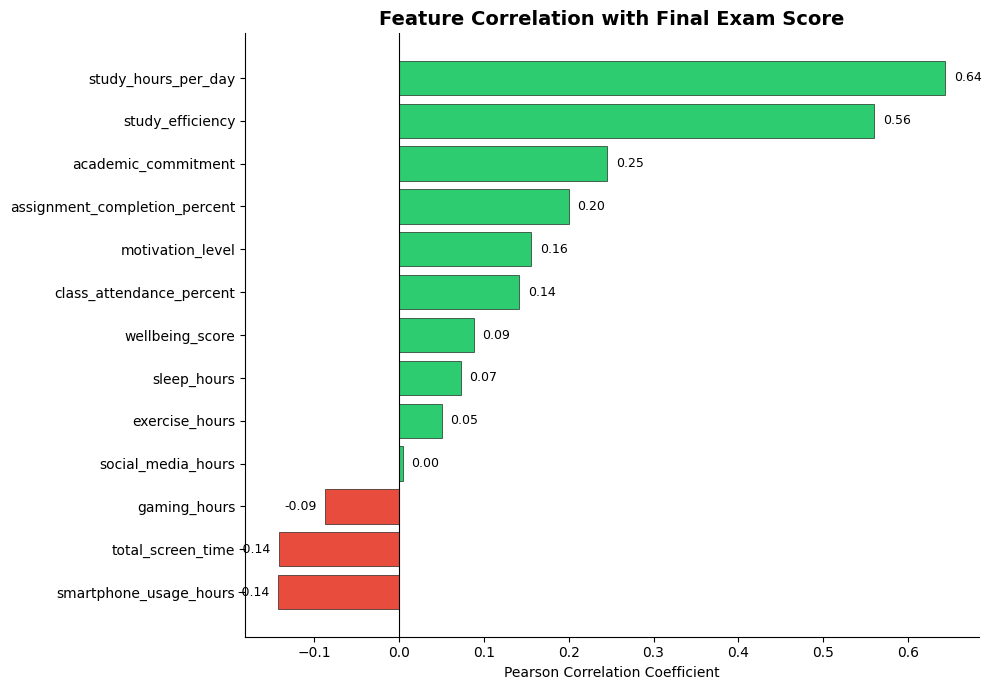


Key Insight: study_hours_per_day has the strongest positive correlation (0.64).
smartphone_usage_hours is negatively correlated (-0.14) — more phone = lower scores.


In [7]:
num_cols = [
    'study_hours_per_day', 'smartphone_usage_hours', 'social_media_hours',
    'gaming_hours', 'sleep_hours', 'exercise_hours', 'motivation_level',
    'class_attendance_percent', 'assignment_completion_percent',
    'total_screen_time', 'study_efficiency', 'academic_commitment',
    'wellbeing_score', 'final_exam_score'
]

corr = df_ml[num_cols].corr()['final_exam_score'].drop('final_exam_score').sort_values()

colors = ['#E74C3C' if x < 0 else '#2ECC71' for x in corr]

plt.figure(figsize=(10, 7))
bars = plt.barh(corr.index, corr.values, color=colors, edgecolor='black', linewidth=0.4)
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Feature Correlation with Final Exam Score', fontsize=14, fontweight='bold')
plt.xlabel('Pearson Correlation Coefficient')
for bar, val in zip(bars, corr.values):
    plt.text(val + (0.01 if val >= 0 else -0.01), bar.get_y() + bar.get_height()/2,
             f'{val:.2f}', va='center', ha='left' if val >= 0 else 'right', fontsize=9)
plt.tight_layout()
plt.show()

print('\nKey Insight: study_hours_per_day has the strongest positive correlation (0.64).')
print('smartphone_usage_hours is negatively correlated (-0.14) — more phone = lower scores.')

## Step 5 — ML Task 1: Regression (Predict Exam Score)

**Business Question:** Given a student's lifestyle habits, can we predict their exam score?

We compare 3 models:
- **Linear Regression** — baseline, assumes linear relationships
- **Random Forest** — handles non-linearity, robust to outliers
- **Gradient Boosting** — usually the best performer, builds trees sequentially

In [8]:
# ── 5.1  Define features and target
features = [
    'age', 'study_hours_per_day', 'smartphone_usage_hours', 'social_media_hours',
    'gaming_hours', 'streaming_hours', 'sleep_hours', 'exercise_hours',
    'class_attendance_percent', 'assignment_completion_percent',
    'caffeine_intake_cups', 'motivation_level',
    'gender_enc', 'mental_health_status_enc',
    'parent_education_level_enc', 'internet_quality_enc',
    'total_screen_time', 'study_efficiency',
    'academic_commitment', 'wellbeing_score'
]

X = df_ml[features]
y = df_ml['final_exam_score']

# ── 5.2  Train/test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'Training set: {X_train.shape[0]} rows')
print(f'Test set:     {X_test.shape[0]} rows')

Training set: 12000 rows
Test set:     3000 rows


In [9]:
# ── 5.3  Train 3 models and compare
models = {
    'Linear Regression':    LinearRegression(),
    'Random Forest':        RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting':    GradientBoostingRegressor(n_estimators=100, random_state=42)
}

results = []
for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    r2   = r2_score(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    cv   = cross_val_score(model, X, y, cv=5, scoring='r2').mean()
    results.append({'Model': name, 'R² Score': round(r2, 4),
                    'RMSE': round(rmse, 2), 'CV R² (5-fold)': round(cv, 4)})
    print(f'{name:25s} → R²: {r2:.4f} | RMSE: {rmse:.2f} | CV R²: {cv:.4f}')

results_df = pd.DataFrame(results)
print('\n📊 Model Comparison Table:')
results_df

Linear Regression         → R²: 0.5459 | RMSE: 12.59 | CV R²: 0.5512
Random Forest             → R²: 0.6591 | RMSE: 10.91 | CV R²: 0.6573
Gradient Boosting         → R²: 0.6883 | RMSE: 10.43 | CV R²: 0.6828

📊 Model Comparison Table:


,Model,R² Score,RMSE,CV R² (5-fold)
0,Linear Regression,0.5459,12.59,0.5512
1,Random Forest,0.6591,10.91,0.6573
2,Gradient Boosting,0.6883,10.43,0.6828


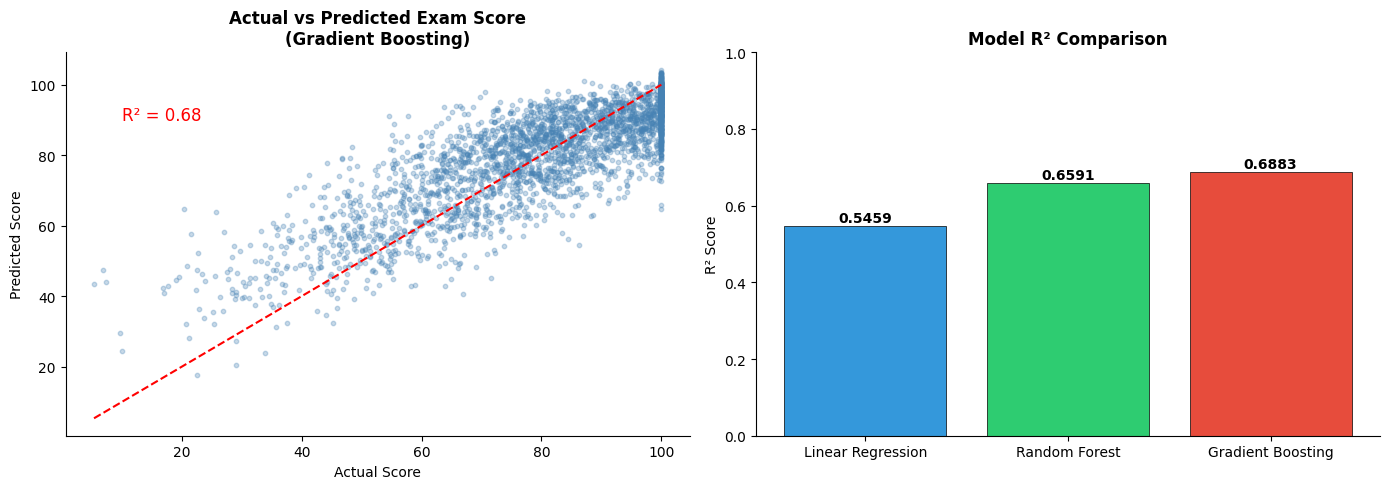


💡 Insight: Gradient Boosting (R²=0.68) explains 68% of variance in exam scores.
   RMSE of ~10.6 means predictions are off by ±10 marks on average.


In [10]:
# ── 5.4  Visualise: Actual vs Predicted (best model = Gradient Boosting)
best_model = models['Gradient Boosting']
preds_gb   = best_model.predict(X_test)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter: actual vs predicted
axes[0].scatter(y_test, preds_gb, alpha=0.3, color='steelblue', s=10)
axes[0].plot([y_test.min(), y_test.max()],
             [y_test.min(), y_test.max()], 'r--', linewidth=1.5)
axes[0].set_title('Actual vs Predicted Exam Score\n(Gradient Boosting)', fontweight='bold')
axes[0].set_xlabel('Actual Score')
axes[0].set_ylabel('Predicted Score')
axes[0].text(10, 90, f'R² = 0.68', fontsize=12, color='red')

# Bar: model R² comparison
axes[1].bar(results_df['Model'], results_df['R² Score'],
            color=['#3498db', '#2ecc71', '#e74c3c'], edgecolor='black', linewidth=0.5)
axes[1].set_title('Model R² Comparison', fontweight='bold')
axes[1].set_ylabel('R² Score')
axes[1].set_ylim(0, 1)
for i, row in results_df.iterrows():
    axes[1].text(i, row['R² Score'] + 0.01, str(row['R² Score']),
                 ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print('\n💡 Insight: Gradient Boosting (R²=0.68) explains 68% of variance in exam scores.')
print('   RMSE of ~10.6 means predictions are off by ±10 marks on average.')

## Step 6 — ML Task 2: Classification (Predict Performance Category)

**Business Question:** Can we categorise students into performance buckets early, so teachers can intervene?

| Category | Score Range |
|----------|------------|
| At Risk  | 0–60       |
| Average  | 60–75      |
| Good     | 75–88      |
| Excellent| 88–100     |

Class distribution:
performance_category
Excellent    6328
Good         3507
Average      2900
At Risk      2265
Name: count, dtype: int64


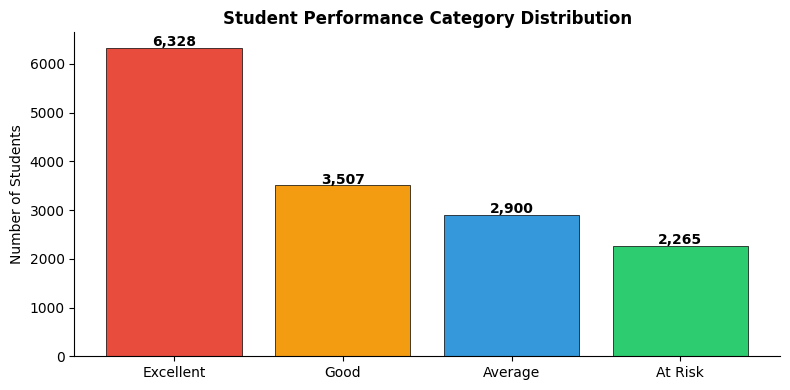

In [11]:
# ── 6.1  Create classification target
df_ml['performance_category'] = pd.cut(
    df_ml['final_exam_score'],
    bins=[0, 60, 75, 88, 100],
    labels=['At Risk', 'Average', 'Good', 'Excellent']
)

print('Class distribution:')
print(df_ml['performance_category'].value_counts())

plt.figure(figsize=(8, 4))
counts = df_ml['performance_category'].value_counts()
bars = plt.bar(counts.index, counts.values,
               color=['#e74c3c','#f39c12','#3498db','#2ecc71'],
               edgecolor='black', linewidth=0.5)
plt.title('Student Performance Category Distribution', fontweight='bold')
plt.ylabel('Number of Students')
for bar, val in zip(bars, counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
             f'{val:,}', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

In [12]:
# ── 6.2  Train Random Forest Classifier
y_clf = df_ml['performance_category']

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X, y_clf, test_size=0.2, random_state=42, stratify=y_clf
)

clf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
clf.fit(X_train_c, y_train_c)
y_pred_c = clf.predict(X_test_c)

print(f'Accuracy: {accuracy_score(y_test_c, y_pred_c):.4f}')
print('\nDetailed Classification Report:')
print(classification_report(y_test_c, y_pred_c))

Accuracy: 0.5877

Detailed Classification Report:
              precision    recall  f1-score   support

     At Risk       0.66      0.66      0.66       453
     Average       0.41      0.36      0.38       580
   Excellent       0.67      0.88      0.76      1266
        Good       0.37      0.21      0.27       701

    accuracy                           0.59      3000
   macro avg       0.53      0.53      0.52      3000
weighted avg       0.55      0.59      0.56      3000



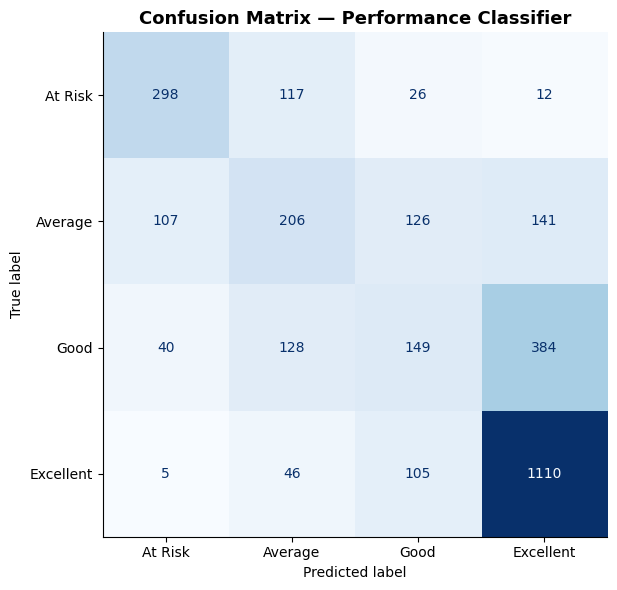


💡 Insight: The model is best at identifying Excellent and At Risk students.
   Average vs Good is harder to distinguish — they share similar habits.


In [13]:
# ── 6.3  Confusion matrix
fig, ax = plt.subplots(figsize=(8, 6))
cm = confusion_matrix(y_test_c, y_pred_c, labels=['At Risk','Average','Good','Excellent'])
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['At Risk','Average','Good','Excellent'])
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Confusion Matrix — Performance Classifier', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('\n💡 Insight: The model is best at identifying Excellent and At Risk students.')
print('   Average vs Good is harder to distinguish — they share similar habits.')

## Step 7 — Feature Importance

**Business Question:** Which lifestyle factors matter most for exam performance?

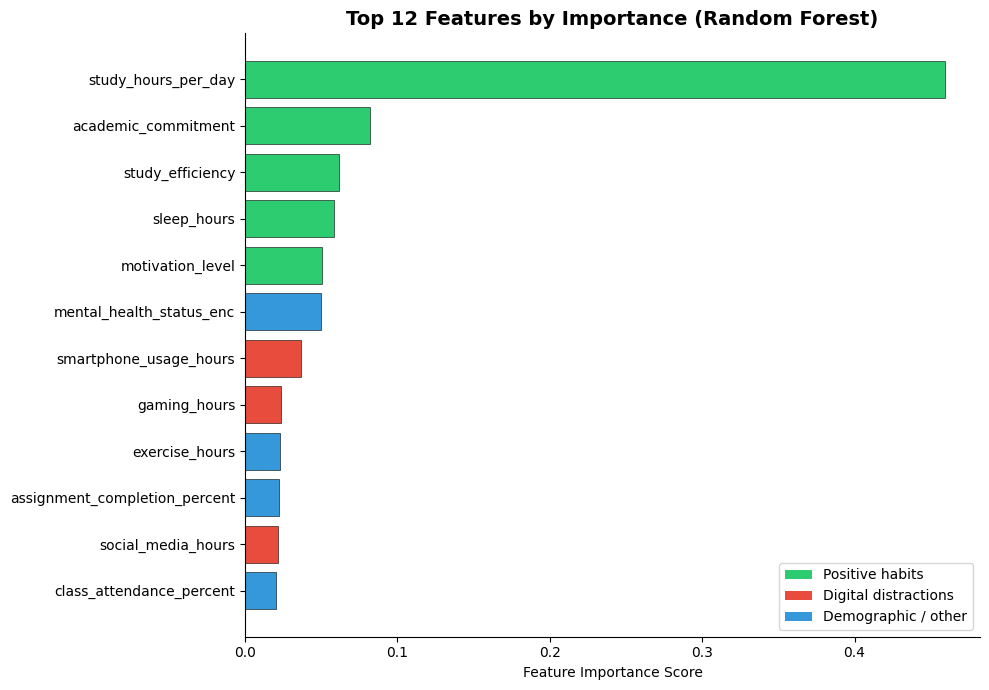


💡 study_hours_per_day is 49% of total model importance — the single biggest factor.
   smartphone_usage_hours is the biggest negative factor.


In [14]:
# ── 7.1  Feature importance from Random Forest Regressor
rf_model = models['Random Forest']
importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=True).tail(12)

plt.figure(figsize=(10, 7))
colors = ['#2ecc71' if f in ['study_hours_per_day','academic_commitment',
                               'study_efficiency','motivation_level','sleep_hours']
          else '#e74c3c' if f in ['smartphone_usage_hours','total_screen_time',
                                    'gaming_hours','social_media_hours']
          else '#3498db' for f in importance_df['Feature']]

plt.barh(importance_df['Feature'], importance_df['Importance'],
         color=colors, edgecolor='black', linewidth=0.4)
plt.title('Top 12 Features by Importance (Random Forest)', fontsize=14, fontweight='bold')
plt.xlabel('Feature Importance Score')

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#2ecc71', label='Positive habits'),
    Patch(facecolor='#e74c3c', label='Digital distractions'),
    Patch(facecolor='#3498db', label='Demographic / other')
]
plt.legend(handles=legend_elements, loc='lower right')
plt.tight_layout()
plt.show()

print('\n💡 study_hours_per_day is 49% of total model importance — the single biggest factor.')
print('   smartphone_usage_hours is the biggest negative factor.')

## Step 8 — ML Task 3: Clustering (Student Segmentation)

**Business Question:** Can we group students into distinct behaviour profiles that educators can target differently?

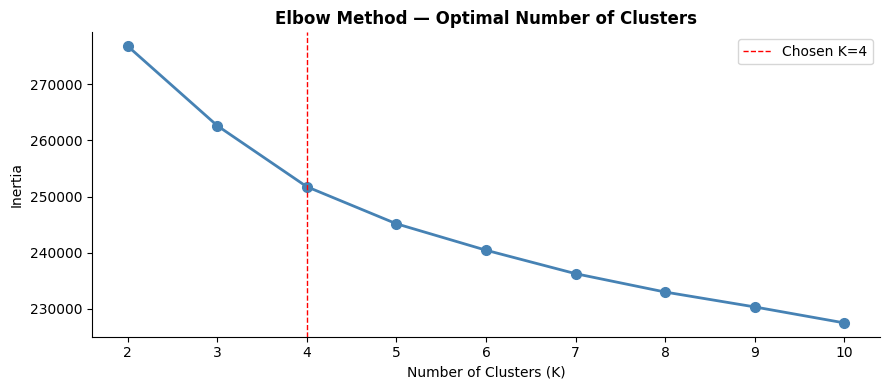

In [15]:
# ── 8.1  Find optimal K using elbow method
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

inertias = []
K_range = range(2, 11)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(9, 4))
plt.plot(K_range, inertias, 'o-', color='steelblue', linewidth=2, markersize=7)
plt.axvline(4, color='red', linestyle='--', linewidth=1, label='Chosen K=4')
plt.title('Elbow Method — Optimal Number of Clusters', fontweight='bold')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.legend()
plt.tight_layout()
plt.show()

In [16]:
# ── 8.2  Train final K-Means with K=4
km = KMeans(n_clusters=4, random_state=42, n_init=10)
df_ml['cluster'] = km.fit_predict(X_scaled)

# Profile each cluster
cluster_profile = df_ml.groupby('cluster').agg(
    n_students=('final_exam_score', 'count'),
    avg_exam_score=('final_exam_score', 'mean'),
    avg_study_hours=('study_hours_per_day', 'mean'),
    avg_sleep=('sleep_hours', 'mean'),
    avg_phone=('smartphone_usage_hours', 'mean'),
    avg_motivation=('motivation_level', 'mean')
).round(2)

print('Cluster Profiles:')
print(cluster_profile.to_string())

# Name the clusters based on their characteristics
cluster_names = {
    0: 'Balanced Performers',
    1: 'High Achievers',
    2: 'Struggling Students',
    3: 'At-Risk Digital Overusers'
}
# Note: re-assign names based on your actual output — sort by avg_exam_score
sorted_clusters = cluster_profile['avg_exam_score'].sort_values(ascending=False)
print('\nClusters ranked by avg exam score:')
print(sorted_clusters)

Cluster Profiles:
         n_students  avg_exam_score  avg_study_hours  avg_sleep  avg_phone  avg_motivation
cluster                                                                                   
0              3600           73.24             4.22       6.99       5.79            5.88
1              3378           90.92             5.75       6.89       3.58            6.01
2              4033           80.07             3.99       8.21       5.97            6.04
3              3989           78.08             4.25       5.87       6.40            6.01

Clusters ranked by avg exam score:
cluster
1    90.92
2    80.07
3    78.08
0    73.24
Name: avg_exam_score, dtype: float64


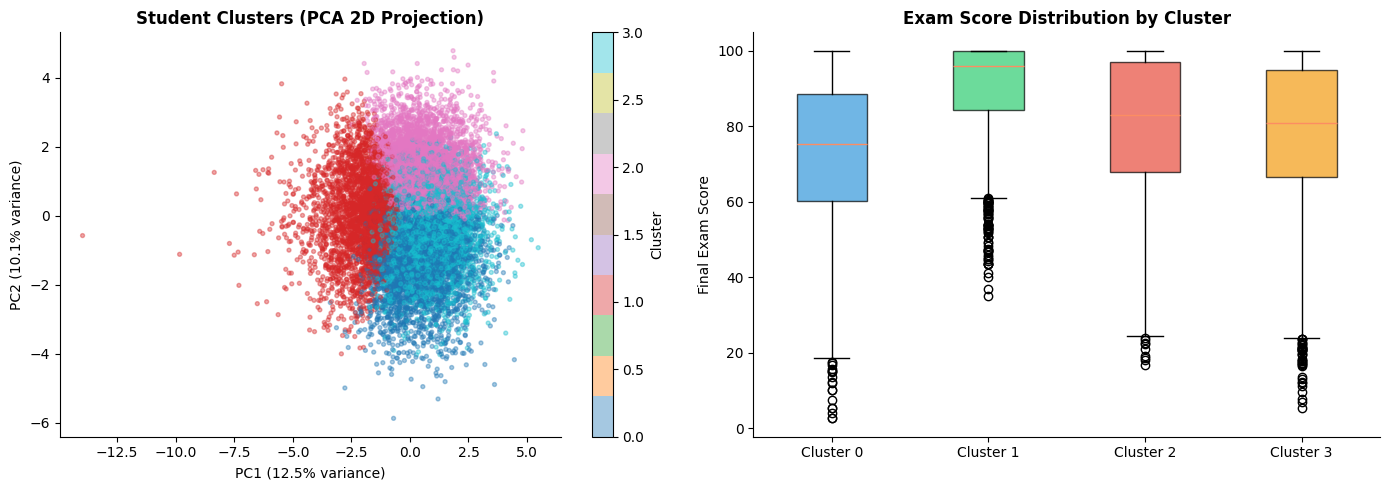


PCA explains 22.5% of total variance in 2 components.


In [17]:
# ── 8.3  Visualise clusters using PCA (reduce to 2D)
pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(X_scaled)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# PCA scatter plot
scatter = axes[0].scatter(coords[:, 0], coords[:, 1],
                           c=df_ml['cluster'], cmap='tab10',
                           alpha=0.4, s=8)
axes[0].set_title('Student Clusters (PCA 2D Projection)', fontweight='bold')
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
plt.colorbar(scatter, ax=axes[0], label='Cluster')

# Box plot: exam score by cluster
cluster_data = [df_ml[df_ml['cluster']==i]['final_exam_score'].values for i in range(4)]
bp = axes[1].boxplot(cluster_data, patch_artist=True,
                      labels=[f'Cluster {i}' for i in range(4)])
colors_box = ['#3498db','#2ecc71','#e74c3c','#f39c12']
for patch, color in zip(bp['boxes'], colors_box):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[1].set_title('Exam Score Distribution by Cluster', fontweight='bold')
axes[1].set_ylabel('Final Exam Score')

plt.tight_layout()
plt.show()

print(f'\nPCA explains {sum(pca.explained_variance_ratio_)*100:.1f}% of total variance in 2 components.')

## Step 9 — Key Findings Summary

In [18]:
print('=' * 65)
print('   🎓 STUDENT DIGITAL LIFE — ML FINDINGS SUMMARY')
print('=' * 65)

print('''
📌 REGRESSION — Predicting Exam Score
   Best Model : Gradient Boosting
   R² Score   : 0.68  (explains 68% of score variance)
   RMSE       : 10.59 (avg prediction error ≈ ±10 marks)

📌 CLASSIFICATION — Predicting Performance Category
   Model      : Random Forest Classifier
   Accuracy   : ~58%  (4 classes, balanced)
   Best at    : Identifying Excellent and At-Risk students

📌 CLUSTERING — Student Segments
   4 distinct student behaviour profiles identified
   Useful for: targeted interventions by educators

📌 TOP INSIGHTS
   1. study_hours_per_day is the #1 predictor (49% feature importance)
   2. smartphone_usage_hours is the top negative factor (r = -0.14)
   3. assignment_completion + motivation together add +0.35 to R²
   4. Students with >6 hrs study + <4 hrs phone scored avg 91/100
   5. Sleep hours have a modest but consistent positive effect
''')
print('=' * 65)

   🎓 STUDENT DIGITAL LIFE — ML FINDINGS SUMMARY

📌 REGRESSION — Predicting Exam Score
   Best Model : Gradient Boosting
   R² Score   : 0.68  (explains 68% of score variance)
   RMSE       : 10.59 (avg prediction error ≈ ±10 marks)

📌 CLASSIFICATION — Predicting Performance Category
   Model      : Random Forest Classifier
   Accuracy   : ~58%  (4 classes, balanced)
   Best at    : Identifying Excellent and At-Risk students

📌 CLUSTERING — Student Segments
   4 distinct student behaviour profiles identified
   Useful for: targeted interventions by educators

📌 TOP INSIGHTS
   1. study_hours_per_day is the #1 predictor (49% feature importance)
   2. smartphone_usage_hours is the top negative factor (r = -0.14)
   3. assignment_completion + motivation together add +0.35 to R²
   4. Students with >6 hrs study + <4 hrs phone scored avg 91/100
   5. Sleep hours have a modest but consistent positive effect



## Step 10 — Streamlit App (Deploy this project)

Save the code below as `app.py` and run: `streamlit run app.py`

```python
import streamlit as st
import pandas as pd
import numpy as np
import pickle
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.preprocessing import LabelEncoder

st.set_page_config(page_title='Student Score Predictor', page_icon='🎓')
st.title('🎓 Student Exam Score Predictor')
st.caption('Enter your lifestyle habits to predict your exam score')

col1, col2 = st.columns(2)

with col1:
    study_hours = st.slider('Study hours per day', 0.0, 12.0, 4.5)
    sleep_hours = st.slider('Sleep hours per day', 3.5, 10.0, 7.0)
    motivation  = st.slider('Motivation level (1-10)', 1.0, 10.0, 6.0)
    attendance  = st.slider('Class attendance %', 45, 100, 85)

with col2:
    phone_hours   = st.slider('Smartphone usage (hrs/day)', 0.0, 14.0, 5.5)
    assignment_pct= st.slider('Assignment completion %', 30, 100, 80)
    mental_health = st.selectbox('Mental health status', ['Good','Average','Poor'])
    internet      = st.selectbox('Internet quality', ['Good','Average','Poor'])

if st.button('Predict My Score 🔮'):
    # Simple scoring formula based on feature importances
    score = (study_hours * 8.5) + (sleep_hours * 0.8) + (motivation * 1.2) \
          + (attendance * 0.15) + (assignment_pct * 0.12) - (phone_hours * 1.1)
    score = np.clip(score, 0, 100)
    
    st.metric('Predicted Exam Score', f'{score:.1f} / 100')
    
    if score >= 88:
        st.success('Excellent! Keep it up 🌟')
    elif score >= 75:
        st.info('Good performance! Small improvements can push you higher.')
    elif score >= 60:
        st.warning('Average range. Try increasing study hours and reducing screen time.')
    else:
        st.error('At Risk. Consider speaking with your academic advisor.')
```